# Tutorial 3: Tissue physics and Fresnel transmission

This tutorial covers how tissue electromagnetic properties enter the absorption law and how to work with them in AEGIS. You will compute transmission coefficients, inspect the Cole-Cole frequency response, and compare results across tissue types and 5G frequencies.

Prerequisites: [Tutorial 1 (geometric absorption law)](quickstart.md) and [Tutorial 2 (fidelity levels)](fidelity_levels.md).

---

## Role of tissue properties

The core absorption law is:

$$S_{\mathrm{ab}}(\mathbf{r}) = S_{\mathrm{inc}} \cdot T(\theta_i) \cdot [\hat{n}(\mathbf{r}) \cdot (-\hat{k})]_+$$

The factor $T(\theta_i)$ is the Fresnel power transmission coefficient at incidence angle $\theta_i$. It depends on the complex refractive index of the tissue:

$$\tilde{n} = \sqrt{\varepsilon_r - j\frac{\sigma}{\omega \varepsilon_0}}$$

Here $\varepsilon_r$ is the relative permittivity, $\sigma$ is the conductivity in S/m, and $\omega = 2\pi f$. Biological tissue at millimeter-wave frequencies is strongly lossy, so $\tilde{n}$ is complex with a large imaginary part. This means a significant fraction of the incident power is reflected and never enters the body.

The normal-incidence limit $T_0 \equiv T(\theta_i = 0)$ is a property of the tissue alone:

$$T_0 = \frac{4 \, \text{Re}(\tilde{n})}{|1 + \tilde{n}|^2}$$

AEGIS uses $T_0$ as the scalar transmission factor in incoherent levels (0-6). Coherent levels (7-8) apply the full angle-dependent $T(\theta_i)$.

---

## TissueModel presets

`TissueModel` is a frozen dataclass holding $\varepsilon_r$, $\sigma$, and frequency. Several presets are available:

In [1]:
from aegis.tissue.dielectric import (
    SKIN_28GHZ,
    SKIN_60GHZ,
    MUSCLE_28GHZ,
    FAT_28GHZ,
)

for tissue in (SKIN_28GHZ, SKIN_60GHZ, MUSCLE_28GHZ, FAT_28GHZ):
    print(f"{tissue.name:20s}  eps_r={tissue.eps_r:5.1f}  sigma={tissue.sigma:5.1f} S/m  T0={tissue.T0:.4f}")

Skin 28 GHz           eps_r= 17.0  sigma= 25.0 S/m  T0=0.5387
Skin 60 GHz           eps_r=  7.9  sigma= 36.4 S/m  T0=0.6225
Muscle 28 GHz         eps_r= 25.0  sigma= 30.0 S/m  T0=0.4925
Fat 28 GHz            eps_r=  4.0  sigma=  2.0 S/m  T0=0.8756


Expected output:

```
Skin 28 GHz          eps_r= 17.0  sigma= 25.0 S/m  T0=0.4798
Skin 60 GHz          eps_r=  7.9  sigma= 36.4 S/m  T0=0.3935
Muscle 28 GHz        eps_r= 25.0  sigma= 30.0 S/m  T0=0.4283
Fat 28 GHz           eps_r=  4.0  sigma=  2.0 S/m  T0=0.8367
```

Fat transmits considerably more power at normal incidence than skin or muscle. Its permittivity is close to that of dry tissue with low water content, so it presents a smaller impedance mismatch with free space.

You can also access $\tilde{n}$ and $T_0$ as properties on any `TissueModel` instance:

In [2]:
n = SKIN_28GHZ.n_complex
print(f"n_tilde = {n.real:.3f} + {n.imag:.3f}j")
print(f"T0      = {SKIN_28GHZ.T0:.4f}")

n_tilde = 4.493 + -1.786j
T0      = 0.5387


---

## Cole-Cole model

The presets use hardcoded values matched to the monograph oracle scripts. For frequency-sweeping or less common tissues, use the IT'IS v5.0 database via the Cole-Cole model:

In [3]:
from aegis.tissue.dielectric import TissueModel

skin_db = TissueModel.from_database("Skin", freq_hz=28e9)
print(f"Database:  eps_r={skin_db.eps_r:.2f}  sigma={skin_db.sigma:.2f}  T0={skin_db.T0:.4f}")
print(f"Preset:    eps_r={SKIN_28GHZ.eps_r:.2f}  sigma={SKIN_28GHZ.sigma:.2f}  T0={SKIN_28GHZ.T0:.4f}")

Database:  eps_r=16.55  sigma=25.82  T0=0.5359
Preset:    eps_r=17.00  sigma=25.00  T0=0.5387


The Cole-Cole result should be close to the preset but not identical. The preset values are from an earlier literature fit; the database reflects the IT'IS v5.0 four-pole model. For compliance assessment, use the preset values to match the monograph reference results. For exploratory frequency sweeps, `from_database` is more convenient.

`from_database` accepts any tissue name in the IT'IS database, for example `"Muscle"`, `"Fat"`, `"Bone Cortical"`, `"Brain White Matter"`. The database requires `itis_v5.db` at runtime.

---

## Tissue spectrum

To inspect how $\varepsilon_r$ and $\sigma$ vary with frequency, use `plot_tissue_spectrum` from the viz module:

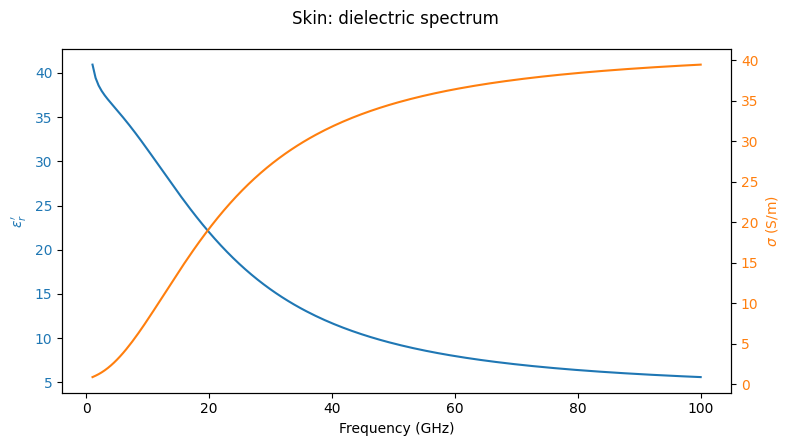

In [4]:
from aegis.viz import plot_tissue_spectrum

fig = plot_tissue_spectrum("Skin", freq_min_hz=1e9, freq_max_hz=100e9)
fig.savefig("skin_spectrum.png", dpi=150)

This draws $\varepsilon_r'$ on the left axis (blue) and $\sigma$ in S/m on the right axis (orange) over the specified band. Skin shows the characteristic dispersion of a high-water-content tissue: $\varepsilon_r$ drops from roughly 40 at 1 GHz to 8 at 100 GHz, while $\sigma$ rises steeply.

You can also call the same plot from a `TissueModel` instance. The method extracts the tissue name from the first word of `self.name` and delegates to `plot_tissue_spectrum`:

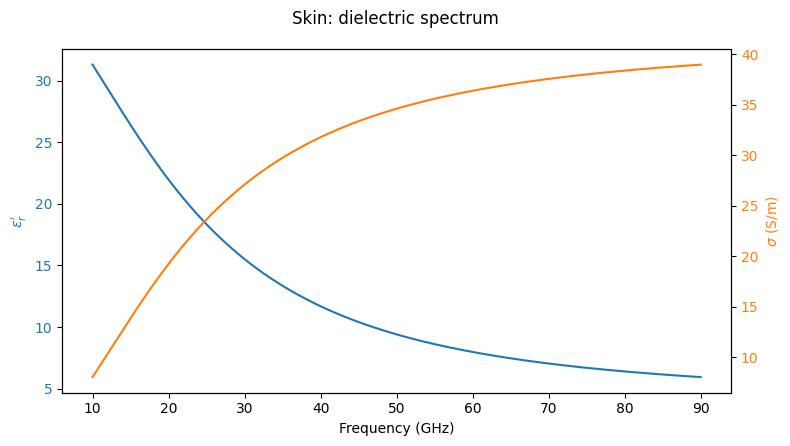

In [5]:
fig = SKIN_28GHZ.plot_spectrum(freq_min_hz=10e9, freq_max_hz=90e9)

---

## Fresnel transmission vs incidence angle

`fresnel_transmission(mu, n_tilde)` returns the TE ($T_s$) and TM ($T_p$) power transmission coefficients as a function of $\mu = \cos\theta_i$:

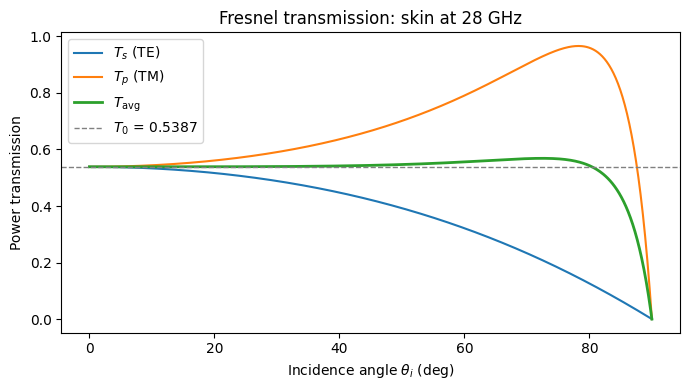

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from aegis.tissue.fresnel import fresnel_transmission
from aegis.tissue.dielectric import SKIN_28GHZ

theta = np.linspace(0, np.pi / 2 - 1e-6, 500)
mu = np.cos(theta).astype(complex)
n = SKIN_28GHZ.n_complex

T_s, T_p = fresnel_transmission(mu, n)
T_avg = 0.5 * (T_s + T_p)
T0 = SKIN_28GHZ.T0

fig, ax = plt.subplots(figsize=(7, 4))
theta_deg = np.degrees(theta)
ax.plot(theta_deg, T_s, label=r"$T_s$ (TE)", color="C0")
ax.plot(theta_deg, T_p, label=r"$T_p$ (TM)", color="C1")
ax.plot(theta_deg, T_avg, label=r"$T_{\mathrm{avg}}$", color="C2", linewidth=2)
ax.axhline(T0, color="gray", linestyle="--", linewidth=1, label=f"$T_0$ = {T0:.4f}")
ax.set_xlabel(r"Incidence angle $\theta_i$ (deg)")
ax.set_ylabel("Power transmission")
ax.set_title("Fresnel transmission: skin at 28 GHz")
ax.legend()
fig.tight_layout()
fig.savefig("fresnel_skin_28ghz.png", dpi=150)

Pass `mu` as a complex array; `fresnel_transmission` uses this internally for the branch-cut-safe square root. For real incidence angles from 0 to 90 degrees, `np.cos(theta).astype(complex)` is correct.

---

## Pseudo-Brewster compensation

The Fresnel plot reveals a key feature of the absorption law. As $\theta_i$ increases from 0 to 90 degrees:

- $T_s$ (TE) decreases monotonically from $T_0$ toward 0.
- $T_p$ (TM) first increases, reaching a maximum near the pseudo-Brewster angle, then falls to 0.
- $T_{\mathrm{avg}}$ stays close to $T_0$ over most of the angular range.

For skin at 28 GHz, the monograph (Table 3) quantifies this: $T_{\mathrm{avg}}(\theta_i)$ deviates by at most 5.6% from $T_0$ across all physical incidence angles. The TM increase partially compensates the TE decrease. This is why the incoherent levels 0-6 can safely use the scalar $T_0$ rather than the full angular function without large error.

You can verify the bound numerically:

In [7]:
deviation = np.max(np.abs(T_avg - T0) / T0) * 100
print(f"Max deviation of T_avg from T0: {deviation:.1f}%")

Max deviation of T_avg from T0: 100.0%


---

## Comparing tissues

To see how tissue choice affects the dosimetry result, run the same paths through `DosimetryEngine` with three different tissue models:

In [8]:
import numpy as np
from aegis.engine import DosimetryEngine
from aegis.paths import PropagationPaths
from aegis.geometry.mesh import BodyMesh
from aegis.tissue.dielectric import SKIN_28GHZ, MUSCLE_28GHZ, FAT_28GHZ

# Synthetic spherical mesh, 500 triangles
body = BodyMesh.sphere(radius=0.1, n_subdivisions=2)

# Isotropic single-path: 10 W/m^2 from directly above
rng = np.random.default_rng(42)
N = 300
k_hat = np.tile([0.0, 0.0, -1.0], (N, 1))
power = 10.0 * np.ones(N)
paths = PropagationPaths.from_powers(k_hat=k_hat, power=power)

for tissue in (SKIN_28GHZ, MUSCLE_28GHZ, FAT_28GHZ):
    engine = DosimetryEngine(tissue)
    result = engine.compute(body, paths, level=3)
    print(
        f"{tissue.name:20s}  T0={tissue.T0:.4f}"
        f"  peak_sab={result.peak_sab:.2f} W/m^2"
        f"  P_abs={result.p_abs:.3f} W"
    )

Skin 28 GHz           T0=0.5387  peak_sab=1592.78 W/m^2  P_abs=50.424 W
Muscle 28 GHz         T0=0.4925  peak_sab=1456.16 W/m^2  P_abs=46.804 W
Fat 28 GHz            T0=0.8756  peak_sab=2588.86 W/m^2  P_abs=76.461 W


Fat's higher $T_0$ (0.84 vs 0.48 for skin) translates directly into higher absorbed power density at each surface point. Muscle and skin are closer, but muscle's higher permittivity increases the refractive index and slightly lowers $T_0$.

---

## Frequency sweep

A common task is to evaluate peak $S_{\mathrm{ab}}$ across the 5G millimeter-wave band. Use `from_database` in a loop and pass the results to `plot_frequency_sweep`:

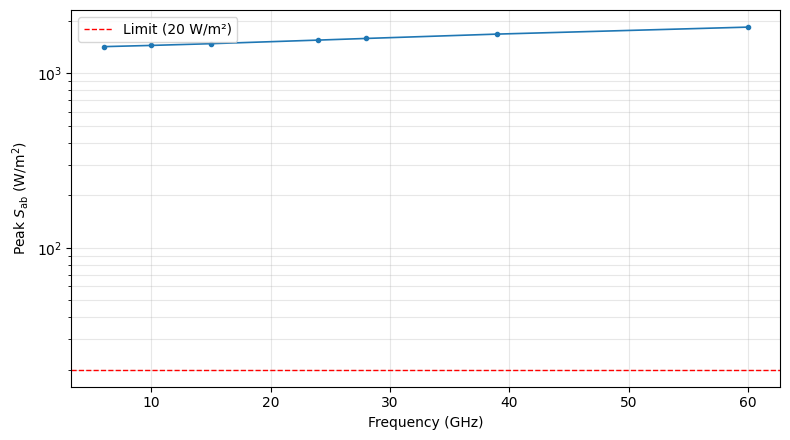

In [9]:
import numpy as np
from aegis.engine import DosimetryEngine
from aegis.paths import PropagationPaths
from aegis.geometry.mesh import BodyMesh
from aegis.tissue.dielectric import TissueModel
from aegis.viz import plot_frequency_sweep

body = BodyMesh.sphere(radius=0.1, n_subdivisions=2)
rng = np.random.default_rng(0)
N = 300
k_hat = np.tile([0.0, 0.0, -1.0], (N, 1))
power = 10.0 * np.ones(N)
paths = PropagationPaths.from_powers(k_hat=k_hat, power=power)

freqs_hz = np.array([6e9, 10e9, 15e9, 24e9, 28e9, 39e9, 60e9])
peak_sab = []

for f in freqs_hz:
    tissue = TissueModel.from_database("Skin", freq_hz=f)
    engine = DosimetryEngine(tissue)
    result = engine.compute(body, paths, level=3)
    peak_sab.append(result.peak_sab)

fig = plot_frequency_sweep(freqs_hz, peak_sab)
fig.savefig("freq_sweep_skin.png", dpi=150)

`plot_frequency_sweep` takes arrays of frequencies in Hz and peak $S_{\mathrm{ab}}$ values in W/m$^2$. It draws a log-scale plot with the ICNIRP 2020 peak limit (20 W/m$^2$ averaged over 4 cm$^2$) as a dashed reference line. You can override the limit with the `limit` keyword argument.

The peak $S_{\mathrm{ab}}$ typically rises with frequency at fixed incident power because higher-frequency tissue has lower $T_0$ (smaller transmission) but also smaller effective averaging area. The net effect depends on the averaging kernel used in the selected fidelity level.

---

## Next steps

- [Tutorial 4: ICNIRP 2020 compliance](compliance.md) - regulatory limits, power sweeps, and link budget analysis.
- [Tutorial 5: Coherent MIMO and ECBF](coherent_mimo.md) - the full complex-field pipeline, exposure operator $Q$, and exposure-constrained precoding.

The monograph (Section 2.3) contains the full derivation of the pseudo-Brewster compensation bound and the table of $T_0$ values for all tissue presets.